# 08 Full Panel + Text Indicators (Descriptive)

This notebook builds the first full monthly analysis panel by merging:
- combined polling + media salience panel (`2013-09` to `2025-12`), and
- monthly text/content indicators (`2013-01` to `2025-12`).

Scope:
- Descriptive reporting only.
- No causal claims.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 220)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PANEL_DIR = PROJECT_ROOT / 'data' / 'panel'
INDICATORS_DIR = PROJECT_ROOT / 'data' / 'indicators'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '08_notebook_figures'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_PANEL_PARQUET = PANEL_DIR / 'monthly_salience_polling_panel_combined_2013_2025.parquet'
COMBINED_PANEL_CSV = PANEL_DIR / 'monthly_salience_polling_panel_combined_2013_2025.csv'

TEXT_MONTHLY_PARQUET = INDICATORS_DIR / 'monthly_text_content_indicators.parquet'
TEXT_MONTHLY_CSV = INDICATORS_DIR / 'monthly_text_content_indicators.csv'

OUT_FULL_PANEL_CSV = PANEL_DIR / 'monthly_full_analysis_panel_2013_2025.csv'
OUT_FULL_PANEL_PARQUET = PANEL_DIR / 'monthly_full_analysis_panel_2013_2025.parquet'
OUT_SHOCK_SUMMARY_CSV = PANEL_DIR / 'full_panel_text_shock_window_summary.csv'

EXPECTED_COMBINED_RANGE = pd.period_range('2013-09', '2025-12', freq='M')
EXPECTED_TEXT_RANGE = pd.period_range('2013-01', '2025-12', freq='M')
EXPECTED_MERGED_RANGE = pd.period_range('2013-09', '2025-12', freq='M')
EXPECTED_MERGED_ROWS = len(EXPECTED_MERGED_RANGE)

SHOCKS = {
    'Cologne': pd.Timestamp('2016-01-01'),
    'Chemnitz': pd.Timestamp('2018-08-01'),
    'Correctiv': pd.Timestamp('2024-01-01'),
}

KEY_TEXT_COLS = [
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
    'negative_threat_terms_per_1000_mean',
    'n_articles_text_indicators',
]

print('COMBINED_PANEL_PARQUET:', COMBINED_PANEL_PARQUET)
print('TEXT_MONTHLY_PARQUET:', TEXT_MONTHLY_PARQUET)
print('OUT_FULL_PANEL_CSV:', OUT_FULL_PANEL_CSV)
print('FIGURES_DIR:', FIGURES_DIR)


COMBINED_PANEL_PARQUET: c:\PythonProjects\AfD-project\data\panel\monthly_salience_polling_panel_combined_2013_2025.parquet
TEXT_MONTHLY_PARQUET: c:\PythonProjects\AfD-project\data\indicators\monthly_text_content_indicators.parquet
OUT_FULL_PANEL_CSV: c:\PythonProjects\AfD-project\data\panel\monthly_full_analysis_panel_2013_2025.csv
FIGURES_DIR: c:\PythonProjects\AfD-project\figures\08_notebook_figures


In [2]:
def load_table(parquet_path: Path, csv_path: Path, label: str) -> pd.DataFrame:
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        print(f'Loaded {label} from parquet: {parquet_path}')
        return df
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f'Loaded {label} from csv: {csv_path}')
        return df
    raise FileNotFoundError(f'Missing {label} input files: {parquet_path} and {csv_path}')


def ensure_month_keys(df: pd.DataFrame, label: str) -> pd.DataFrame:
    out = df.copy()

    if 'year_month' in out.columns:
        ym = out['year_month'].astype(str).str.strip()
    elif 'month' in out.columns:
        ym = out['month'].astype(str).str.strip()
    elif 'month_dt' in out.columns:
        dt = pd.to_datetime(out['month_dt'], errors='coerce')
        if dt.isna().any():
            raise ValueError(f'{label}: month_dt contains unparseable values')
        ym = dt.dt.strftime('%Y-%m')
    else:
        raise ValueError(f'{label}: cannot derive month key (need year_month/month/month_dt)')

    dt_from_ym = pd.to_datetime(ym + '-01', errors='coerce')
    if dt_from_ym.isna().any():
        bad = ym[dt_from_ym.isna()].head(10).tolist()
        raise ValueError(f'{label}: unparseable month values: {bad}')

    out['year_month'] = dt_from_ym.dt.strftime('%Y-%m')
    out['month_dt'] = dt_from_ym
    out['month'] = out['year_month']
    out['year'] = out['month_dt'].dt.year
    out['month_num'] = out['month_dt'].dt.month
    return out


combined_raw = load_table(COMBINED_PANEL_PARQUET, COMBINED_PANEL_CSV, 'combined panel')
text_raw = load_table(TEXT_MONTHLY_PARQUET, TEXT_MONTHLY_CSV, 'monthly text indicators')

combined = ensure_month_keys(combined_raw, 'combined panel')
text_monthly = ensure_month_keys(text_raw, 'monthly text indicators')

print('combined shape:', combined.shape)
print('text_monthly shape:', text_monthly.shape)


Loaded combined panel from parquet: c:\PythonProjects\AfD-project\data\panel\monthly_salience_polling_panel_combined_2013_2025.parquet
Loaded monthly text indicators from parquet: c:\PythonProjects\AfD-project\data\indicators\monthly_text_content_indicators.parquet
combined shape: (148, 41)
text_monthly shape: (156, 31)


In [3]:
required_text_cols = KEY_TEXT_COLS.copy()
missing_text_cols = [c for c in required_text_cols if c not in text_monthly.columns]
if missing_text_cols:
    raise ValueError(f'Missing required text indicator columns: {missing_text_cols}')

if combined['year_month'].duplicated().any():
    dupes = combined.loc[combined['year_month'].duplicated(), 'year_month'].tolist()
    raise ValueError(f'Combined panel has duplicate months: {dupes[:10]}')

if text_monthly['year_month'].duplicated().any():
    dupes = text_monthly.loc[text_monthly['year_month'].duplicated(), 'year_month'].tolist()
    raise ValueError(f'Text indicators have duplicate months: {dupes[:10]}')

combined_periods = pd.PeriodIndex(combined['year_month'], freq='M')
text_periods = pd.PeriodIndex(text_monthly['year_month'], freq='M')

missing_combined_months = EXPECTED_COMBINED_RANGE.difference(combined_periods)
extra_combined_months = combined_periods.difference(EXPECTED_COMBINED_RANGE)
missing_text_months = EXPECTED_TEXT_RANGE.difference(text_periods)
extra_text_months = text_periods.difference(EXPECTED_TEXT_RANGE)

if len(missing_combined_months) > 0 or len(extra_combined_months) > 0:
    raise ValueError(
        'Combined panel coverage mismatch. '
        f'missing={ [p.strftime("%Y-%m") for p in missing_combined_months] }, '
        f'extra={ [p.strftime("%Y-%m") for p in extra_combined_months] }'
    )

if len(missing_text_months) > 0 or len(extra_text_months) > 0:
    raise ValueError(
        'Text indicator coverage mismatch. '
        f'missing={ [p.strftime("%Y-%m") for p in missing_text_months] }, '
        f'extra={ [p.strftime("%Y-%m") for p in extra_text_months] }'
    )

print('Validation summary before merge:')
print('combined months:', combined['year_month'].min(), 'to', combined['year_month'].max(), 'rows=', len(combined))
print('text months:', text_monthly['year_month'].min(), 'to', text_monthly['year_month'].max(), 'rows=', len(text_monthly))


Validation summary before merge:
combined months: 2013-09 to 2025-12 rows= 148
text months: 2013-01 to 2025-12 rows= 156


In [4]:
text_merge_cols = [
    'year_month',
    'text_indicator_month_has_articles',
    'n_articles_text_indicators',
    'mean_word_count',
    'median_word_count',
    'total_word_count',
    'migration_terms_per_1000_mean',
    'migration_terms_total',
    'share_articles_with_migration_terms',
    'security_terms_per_1000_mean',
    'security_terms_total',
    'share_articles_with_security_terms',
    'afd_far_right_terms_per_1000_mean',
    'afd_far_right_terms_total',
    'share_articles_with_afd_far_right_terms',
    'remigration_democracy_terms_per_1000_mean',
    'remigration_democracy_terms_total',
    'share_articles_with_remigration_democracy_terms',
    'negative_threat_terms_per_1000_mean',
    'negative_threat_terms_total',
    'share_articles_with_negative_threat_terms',
    'security_share_of_migration_context_mean',
    'migration_terms_per_1000_median',
    'security_terms_per_1000_median',
    'afd_far_right_terms_per_1000_median',
    'remigration_democracy_terms_per_1000_median',
    'negative_threat_terms_per_1000_median',
]
text_merge_cols = [c for c in text_merge_cols if c in text_monthly.columns]

merged = combined.merge(
    text_monthly[text_merge_cols],
    on='year_month',
    how='left',
    validate='one_to_one',
)

merged['month_dt'] = pd.to_datetime(merged['year_month'] + '-01', errors='coerce')
merged['month'] = merged['year_month']
merged['year'] = merged['month_dt'].dt.year
merged['month_num'] = merged['month_dt'].dt.month

if len(merged) != EXPECTED_MERGED_ROWS:
    raise ValueError(f'Merged panel row mismatch: got {len(merged)}, expected {EXPECTED_MERGED_ROWS}')
if merged['year_month'].duplicated().any():
    raise ValueError('Merged panel has duplicate months')

merged_periods = pd.PeriodIndex(merged['year_month'], freq='M')
missing_merged_months = EXPECTED_MERGED_RANGE.difference(merged_periods)
extra_merged_months = merged_periods.difference(EXPECTED_MERGED_RANGE)
if len(missing_merged_months) > 0 or len(extra_merged_months) > 0:
    raise ValueError(
        'Merged panel coverage mismatch. '
        f'missing={ [p.strftime("%Y-%m") for p in missing_merged_months] }, '
        f'extra={ [p.strftime("%Y-%m") for p in extra_merged_months] }'
    )

for col in ['afd_poll_support_mean', 'nexis_total_results']:
    if col not in merged.columns:
        raise ValueError(f'Merged panel missing required column: {col}')
    if merged[col].isna().any():
        bad = merged.loc[merged[col].isna(), 'year_month'].tolist()[:10]
        raise ValueError(f'Merged panel has missing values in {col}. Sample months: {bad}')

for col in required_text_cols:
    if col not in merged.columns:
        raise ValueError(f'Merged panel missing required text column after merge: {col}')
    if merged[col].isna().any():
        bad = merged.loc[merged[col].isna(), 'year_month'].tolist()[:10]
        raise ValueError(f'Merged panel has missing text values in {col}. Sample months: {bad}')

ordered_front = [
    'month', 'year_month', 'month_dt', 'year', 'month_num',
    'polling_source_block', 'collection_method', 'afd_poll_support_mean',
    'nexis_total_results', 'media_salience_volume_raw', 'media_salience_volume_log1p',
    'media_salience_volume_z', 'media_salience_volume_z_panel',
    'n_articles_text_indicators',
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
    'negative_threat_terms_per_1000_mean',
]
ordered_front = [c for c in ordered_front if c in merged.columns]
other_cols = [c for c in merged.columns if c not in ordered_front]
merged_out = merged[ordered_front + other_cols].sort_values('month_dt').reset_index(drop=True)

merged_out.to_csv(OUT_FULL_PANEL_CSV, index=False)
merged_out.to_parquet(OUT_FULL_PANEL_PARQUET, index=False)

print('Saved merged full panel CSV:', OUT_FULL_PANEL_CSV)
print('Saved merged full panel parquet:', OUT_FULL_PANEL_PARQUET)
print('merged_out shape:', merged_out.shape)
print('coverage:', merged_out['year_month'].min(), 'to', merged_out['year_month'].max())
print('Preview:')
print(merged_out.head(5).to_string(index=False))


Saved merged full panel CSV: c:\PythonProjects\AfD-project\data\panel\monthly_full_analysis_panel_2013_2025.csv
Saved merged full panel parquet: c:\PythonProjects\AfD-project\data\panel\monthly_full_analysis_panel_2013_2025.parquet
merged_out shape: (148, 67)
coverage: 2013-09 to 2025-12
Preview:
  month year_month   month_dt  year  month_num        polling_source_block                      collection_method  afd_poll_support_mean  nexis_total_results  media_salience_volume_raw  media_salience_volume_log1p  media_salience_volume_z  media_salience_volume_z_panel  n_articles_text_indicators  migration_terms_per_1000_mean  security_terms_per_1000_mean  afd_far_right_terms_per_1000_mean  remigration_democracy_terms_per_1000_mean  negative_threat_terms_per_1000_mean                                                                       notes  afd_poll_support_median  afd_poll_support_sd  n_polls  n_pollsters first_poll_date last_poll_date  afd_poll_support_z_combined  raw_article_count  down

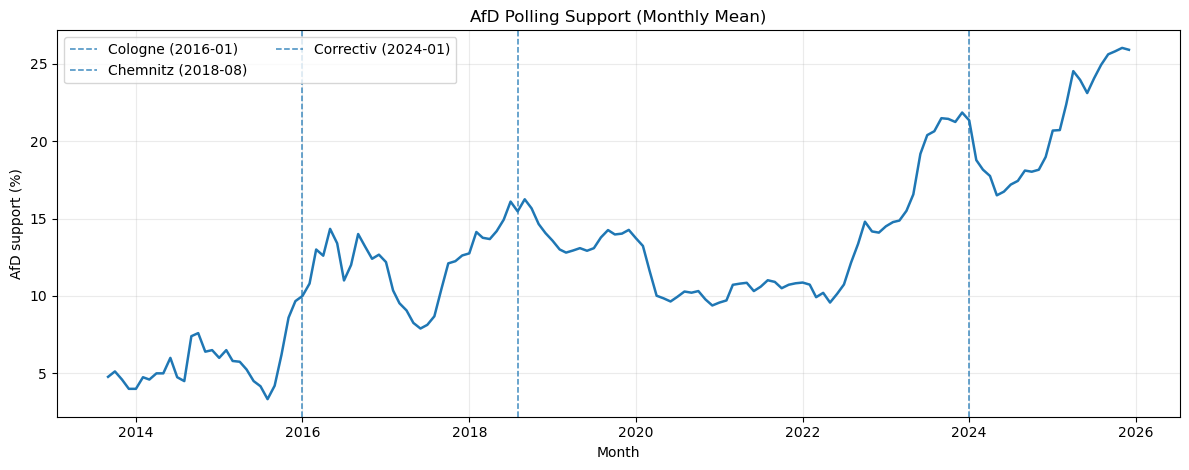

Saved: c:\PythonProjects\AfD-project\figures\08_notebook_figures\afd_polling_support_mean.png


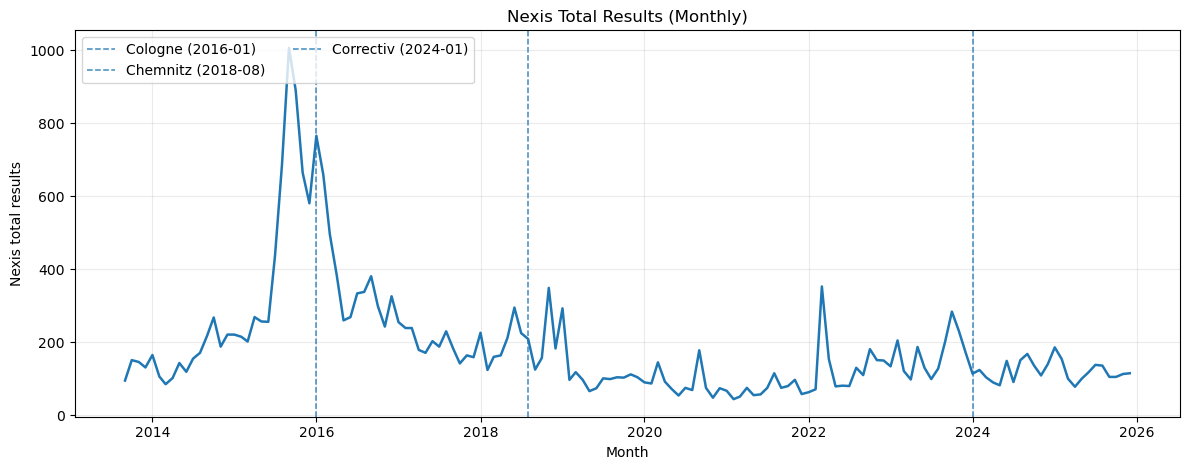

Saved: c:\PythonProjects\AfD-project\figures\08_notebook_figures\nexis_total_results_monthly.png


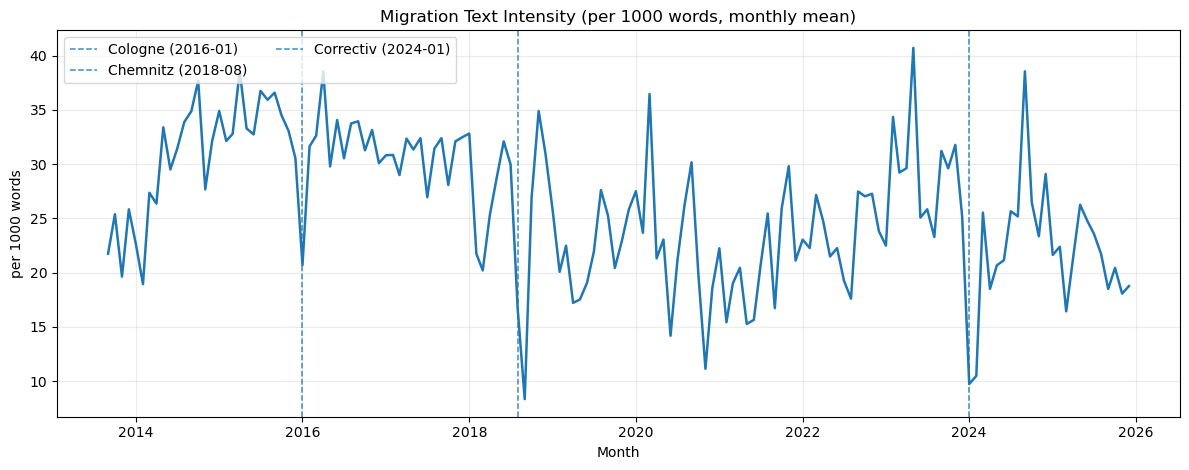

Saved: c:\PythonProjects\AfD-project\figures\08_notebook_figures\migration_text_intensity_monthly.png


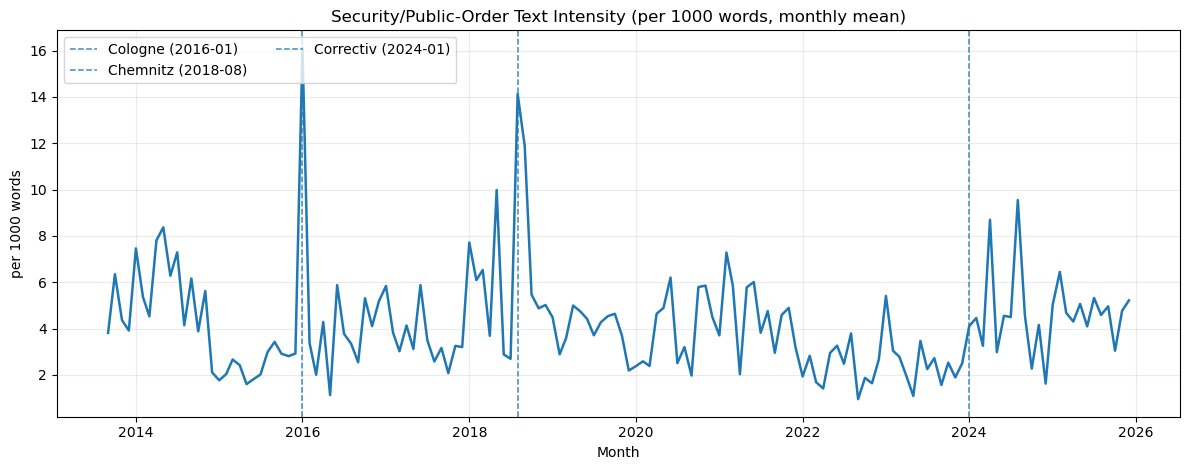

Saved: c:\PythonProjects\AfD-project\figures\08_notebook_figures\security_text_intensity_monthly.png


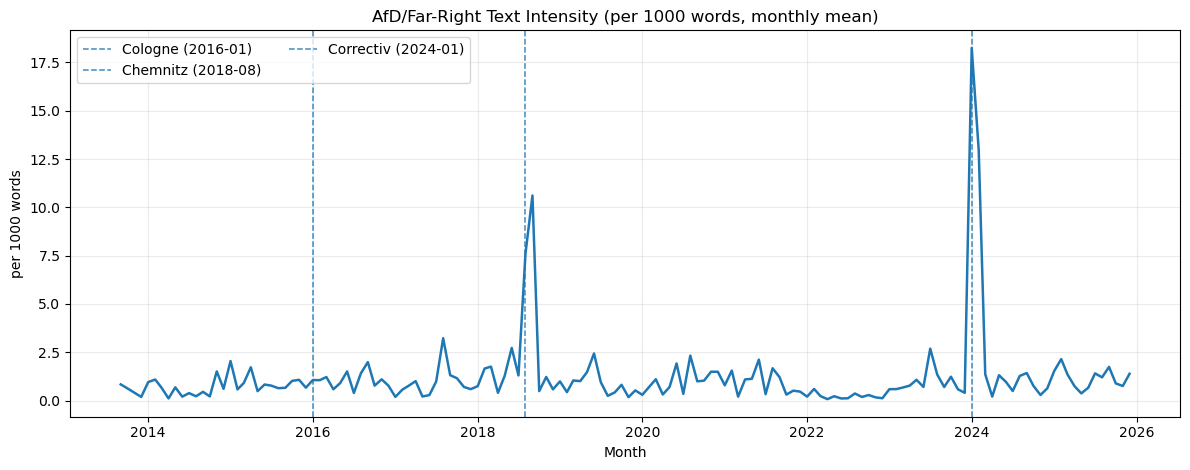

Saved: c:\PythonProjects\AfD-project\figures\08_notebook_figures\afd_far_right_text_intensity_monthly.png


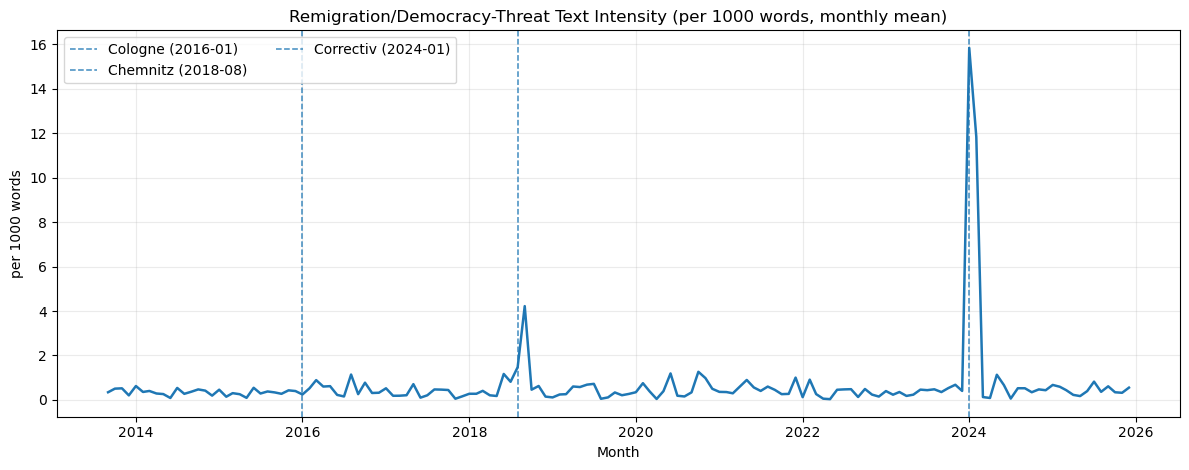

Saved: c:\PythonProjects\AfD-project\figures\08_notebook_figures\remigration_democracy_text_intensity_monthly.png


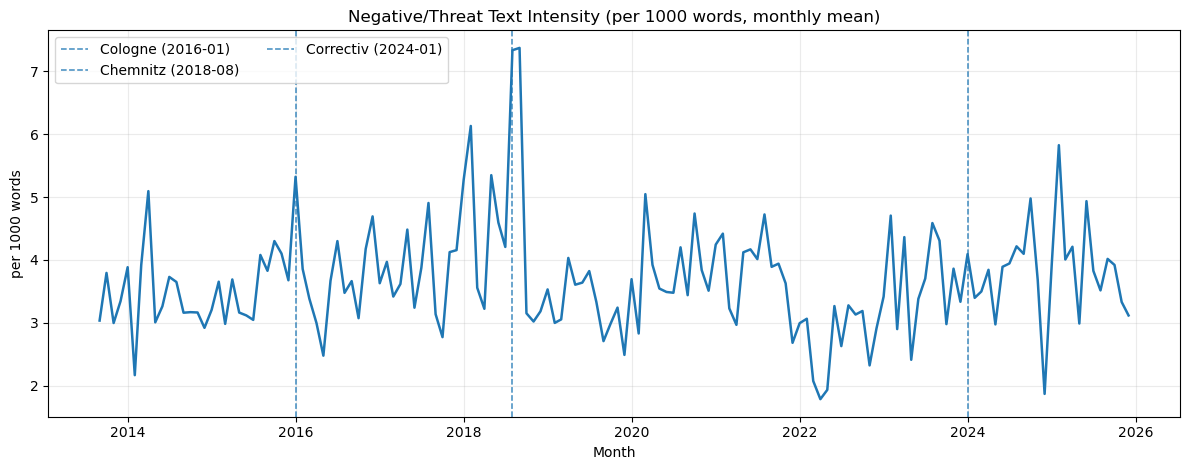

Saved: c:\PythonProjects\AfD-project\figures\08_notebook_figures\negative_threat_text_intensity_monthly.png


In [5]:
def add_shock_lines(ax):
    for label, dt in SHOCKS.items():
        ax.axvline(dt, linestyle='--', linewidth=1.1, alpha=0.85, label=f'{label} ({dt.strftime("%Y-%m")})')

plot_specs = [
    ('afd_poll_support_mean', 'AfD Polling Support (Monthly Mean)', 'AfD support (%)', 'afd_polling_support_mean.png'),
    ('nexis_total_results', 'Nexis Total Results (Monthly)', 'Nexis total results', 'nexis_total_results_monthly.png'),
    ('migration_terms_per_1000_mean', 'Migration Text Intensity (per 1000 words, monthly mean)', 'per 1000 words', 'migration_text_intensity_monthly.png'),
    ('security_terms_per_1000_mean', 'Security/Public-Order Text Intensity (per 1000 words, monthly mean)', 'per 1000 words', 'security_text_intensity_monthly.png'),
    ('afd_far_right_terms_per_1000_mean', 'AfD/Far-Right Text Intensity (per 1000 words, monthly mean)', 'per 1000 words', 'afd_far_right_text_intensity_monthly.png'),
    ('remigration_democracy_terms_per_1000_mean', 'Remigration/Democracy-Threat Text Intensity (per 1000 words, monthly mean)', 'per 1000 words', 'remigration_democracy_text_intensity_monthly.png'),
    ('negative_threat_terms_per_1000_mean', 'Negative/Threat Text Intensity (per 1000 words, monthly mean)', 'per 1000 words', 'negative_threat_text_intensity_monthly.png'),
]

for col, title, ylab, fname in plot_specs:
    fig, ax = plt.subplots(figsize=(12, 4.8))
    ax.plot(merged_out['month_dt'], pd.to_numeric(merged_out[col], errors='coerce'), linewidth=1.8)
    add_shock_lines(ax)
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel(ylab)
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', ncol=2)
    fig.tight_layout()
    out = FIGURES_DIR / fname
    fig.savefig(out, dpi=150)
    plt.show()
    print('Saved:', out)


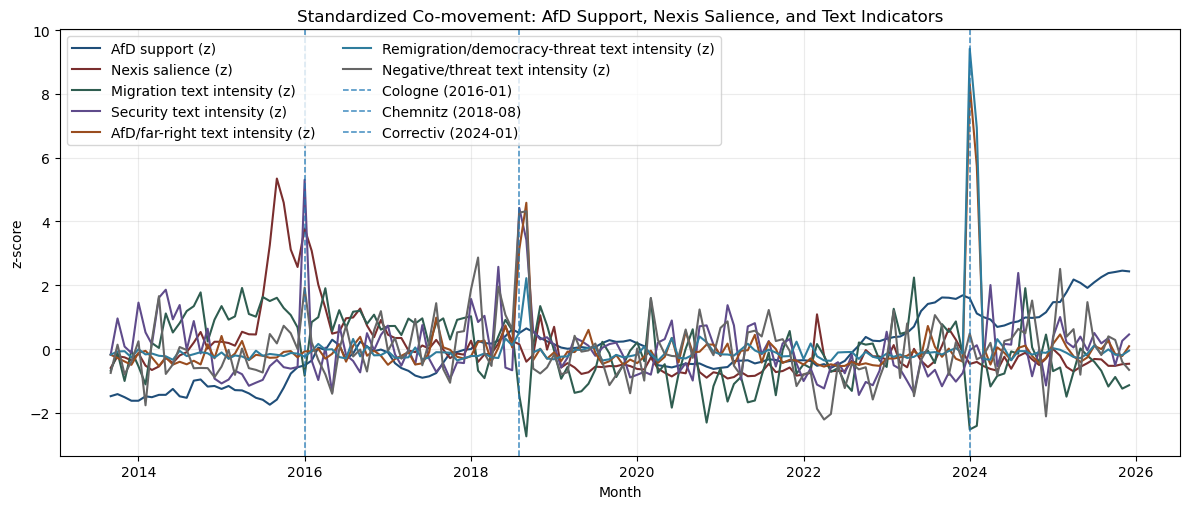

Saved: c:\PythonProjects\AfD-project\figures\08_notebook_figures\standardized_comovement_full_panel.png


In [6]:
def zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    mu = s.mean()
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - mu) / sd

co_cols = [
    'afd_poll_support_mean',
    'nexis_total_results',
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
    'negative_threat_terms_per_1000_mean',
]
co = merged_out[['month_dt'] + co_cols].copy()
for c in co_cols:
    co[c + '_z'] = zscore(co[c])

fig, ax = plt.subplots(figsize=(12, 5.2))
color_map = {
    'afd_poll_support_mean_z': '#1f4e79',
    'nexis_total_results_z': '#7a2e2e',
    'migration_terms_per_1000_mean_z': '#2f5d50',
    'security_terms_per_1000_mean_z': '#5f4b8b',
    'afd_far_right_terms_per_1000_mean_z': '#9a4d1f',
    'remigration_democracy_terms_per_1000_mean_z': '#2f7d9d',
    'negative_threat_terms_per_1000_mean_z': '#666666',
}
label_map = {
    'afd_poll_support_mean_z': 'AfD support (z)',
    'nexis_total_results_z': 'Nexis salience (z)',
    'migration_terms_per_1000_mean_z': 'Migration text intensity (z)',
    'security_terms_per_1000_mean_z': 'Security text intensity (z)',
    'afd_far_right_terms_per_1000_mean_z': 'AfD/far-right text intensity (z)',
    'remigration_democracy_terms_per_1000_mean_z': 'Remigration/democracy-threat text intensity (z)',
    'negative_threat_terms_per_1000_mean_z': 'Negative/threat text intensity (z)',
}

for c in [x + '_z' for x in co_cols]:
    ax.plot(co['month_dt'], co[c], linewidth=1.5, label=label_map[c], color=color_map[c])

add_shock_lines(ax)
ax.set_title('Standardized Co-movement: AfD Support, Nexis Salience, and Text Indicators')
ax.set_xlabel('Month')
ax.set_ylabel('z-score')
ax.grid(alpha=0.25)
ax.legend(loc='upper left', ncol=2)
fig.tight_layout()
out = FIGURES_DIR / 'standardized_comovement_full_panel.png'
fig.savefig(out, dpi=150)
plt.show()
print('Saved:', out)


In [7]:
summary_vars = ['afd_poll_support_mean'] + KEY_TEXT_COLS[:-1]  # keep intensity variables + AfD support
summary_rows = []

for shock_label, shock_month in SHOCKS.items():
    for win in [3, 6]:
        w = merged_out[
            (merged_out['month_dt'] >= shock_month - pd.DateOffset(months=win))
            & (merged_out['month_dt'] <= shock_month + pd.DateOffset(months=win))
        ].copy()
        w['rel_month'] = (
            (w['month_dt'].dt.year - shock_month.year) * 12
            + (w['month_dt'].dt.month - shock_month.month)
        ).astype(int)

        pre = w[w['rel_month'] < 0]
        post = w[w['rel_month'] > 0]
        shock_row = w[w['rel_month'] == 0]

        for var in summary_vars:
            summary_rows.append({
                'shock_label': shock_label,
                'shock_month': shock_month.strftime('%Y-%m'),
                'window_months': win,
                'variable': var,
                'pre_mean': pre[var].mean(),
                'post_mean': post[var].mean(),
                'change_post_minus_pre': post[var].mean() - pre[var].mean(),
                'shock_month_value': shock_row[var].iloc[0] if len(shock_row) == 1 else np.nan,
                'n_months_pre': len(pre),
                'n_months_post': len(post),
            })

shock_summary = pd.DataFrame(summary_rows)
shock_summary.to_csv(OUT_SHOCK_SUMMARY_CSV, index=False)

print('Saved shock-window summary:', OUT_SHOCK_SUMMARY_CSV)
print(shock_summary.head(24).to_string(index=False))

compact = shock_summary[['shock_label','shock_month','window_months','variable','change_post_minus_pre','shock_month_value']].copy()
print()
print('Compact summary (change post-pre):')
print(compact.to_string(index=False))


Saved shock-window summary: c:\PythonProjects\AfD-project\data\panel\full_panel_text_shock_window_summary.csv
shock_label shock_month  window_months                                  variable  pre_mean  post_mean  change_post_minus_pre  shock_month_value  n_months_pre  n_months_post
    Cologne     2016-01              3                     afd_poll_support_mean  8.155556  12.133333               3.977778          10.000000             3              3
    Cologne     2016-01              3             migration_terms_per_1000_mean 32.702058  34.262949               1.560890          20.690986             3              3
    Cologne     2016-01              3              security_terms_per_1000_mean  2.882604   3.224113               0.341509          16.113945             3              3
    Cologne     2016-01              3         afd_far_right_terms_per_1000_mean  0.921007   0.954998               0.033991           1.061618             3              3
    Cologne     2016-01  

## Interpretation Notes (Descriptive)

- The merged panel now aligns polling, volume salience, and text-content indicators in a single monthly file for `2013-09` to `2025-12`.
- Shock-month windows above are descriptive diagnostics only (local level shifts around predefined dates).
- These results do not establish causal effects; they are intended to guide later modeling choices.


In [8]:
print('Final validation checkpoint:')
print('full panel rows:', len(merged_out))
print('full panel coverage:', merged_out['year_month'].min(), 'to', merged_out['year_month'].max())
print('missing AfD support:', int(merged_out['afd_poll_support_mean'].isna().sum()))
print('missing Nexis salience:', int(merged_out['nexis_total_results'].isna().sum()))
for col in KEY_TEXT_COLS:
    print(f'missing {col}:', int(merged_out[col].isna().sum()))


Final validation checkpoint:
full panel rows: 148
full panel coverage: 2013-09 to 2025-12
missing AfD support: 0
missing Nexis salience: 0
missing migration_terms_per_1000_mean: 0
missing security_terms_per_1000_mean: 0
missing afd_far_right_terms_per_1000_mean: 0
missing remigration_democracy_terms_per_1000_mean: 0
missing negative_threat_terms_per_1000_mean: 0
missing n_articles_text_indicators: 0
